In [ ]:
import os
from pathlib import Path
from PIL import Image
import torch
import torchvision.transforms as T
import lpips

PROJECT_ROOT = Path("/path/Sample-Adaptive-Diffusion-Steps")
DDR_ROOT = PROJECT_ROOT / "external" / "ddrm"
device = "cuda" if torch.cuda.is_available() else "cpu"

lpips_model = lpips.LPIPS(net="alex").to(device)
to_tensor = T.ToTensor()

def load_img(path):
    img = Image.open(path).convert("RGB")
    return to_tensor(img).unsqueeze(0).to(device)

def to_lpips_range(x):
    return x * 2 - 1

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/projectnb/cs505am/students/hbbeth/DDIM/Sample-Adaptive-Diffusion-Steps/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/projectnb/cs505am/students/hbbeth/DDIM/Sample-Adaptive-Diffusion-Steps/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /projectnb/cs505am/students/hbbeth/DDIM/Sample-Adaptive-Diffusion-Steps/.venv/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth


In [2]:
# EPS = 0.5 exp
# run_dirs = {
#     5:  DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k5_strongerblur",
#     10: DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k10_strongerblur",
#     20: DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k20_strongerblur",
#     30: DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k30_strongerblur",
#     50: DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k50_strongerblur",
#     100: DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k100_strongerblur",
# }

# EPS = 0.3 exp
run_dirs = {
    5:  DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k5_strongerblur",
    10: DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k10_strongerblur",
    20: DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k20_strongerblur",
    30: DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k30_strongerblur",
    50: DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k50_strongerblur",
    100: DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k100_strongerblur",
}

In [21]:
results = []

num_images = 100

for k, folder in run_dirs.items():
    for idx in range(num_images):
        orig_path = folder / f"orig_{idx}.png"
        restored_path = folder / f"{idx}_-1.png"

        x0 = load_img(orig_path)
        xr = load_img(restored_path)

        with torch.no_grad():
            score = lpips_model(
                to_lpips_range(xr),
                to_lpips_range(x0)
            ).item()

        results.append((idx, k, score))
        print(f"image={idx}, steps={k}, LPIPS={score:.5f}")

image=0, steps=5, LPIPS=0.04911
image=1, steps=5, LPIPS=0.06771
image=2, steps=5, LPIPS=0.03556
image=3, steps=5, LPIPS=0.03198
image=4, steps=5, LPIPS=0.07581
image=5, steps=5, LPIPS=0.05349
image=6, steps=5, LPIPS=0.03879
image=7, steps=5, LPIPS=0.05122
image=8, steps=5, LPIPS=0.04963
image=9, steps=5, LPIPS=0.01778
image=10, steps=5, LPIPS=0.04609
image=11, steps=5, LPIPS=0.03844
image=12, steps=5, LPIPS=0.02987
image=13, steps=5, LPIPS=0.03931
image=14, steps=5, LPIPS=0.04307
image=15, steps=5, LPIPS=0.01613
image=16, steps=5, LPIPS=0.04181
image=17, steps=5, LPIPS=0.06801
image=18, steps=5, LPIPS=0.02876
image=19, steps=5, LPIPS=0.06788
image=20, steps=5, LPIPS=0.06968
image=21, steps=5, LPIPS=0.04437
image=22, steps=5, LPIPS=0.04839
image=23, steps=5, LPIPS=0.04095
image=24, steps=5, LPIPS=0.06907
image=25, steps=5, LPIPS=0.04354
image=26, steps=5, LPIPS=0.03010
image=27, steps=5, LPIPS=0.03465
image=28, steps=5, LPIPS=0.03437
image=29, steps=5, LPIPS=0.04686
image=30, steps=5, L

In [4]:
from collections import defaultdict

best_per_image = defaultdict(lambda: (None, float("inf")))

for idx, k, score in results:
    if score < best_per_image[idx][1]:
        best_per_image[idx] = (k, score)

print("\nBest step count per image:")
for idx in sorted(best_per_image):
    k, score = best_per_image[idx]
    print(f"image={idx}: best_k={k}, best_LPIPS={score:.5f}")


Best step count per image:
image=0: best_k=100, best_LPIPS=0.00531
image=1: best_k=100, best_LPIPS=0.01438
image=2: best_k=100, best_LPIPS=0.02004
image=3: best_k=100, best_LPIPS=0.00395
image=4: best_k=100, best_LPIPS=0.03047
image=5: best_k=100, best_LPIPS=0.00785
image=6: best_k=100, best_LPIPS=0.00267
image=7: best_k=100, best_LPIPS=0.00482
image=8: best_k=100, best_LPIPS=0.00717
image=9: best_k=100, best_LPIPS=0.00202
image=10: best_k=100, best_LPIPS=0.02805
image=11: best_k=100, best_LPIPS=0.01107
image=12: best_k=100, best_LPIPS=0.01092
image=13: best_k=100, best_LPIPS=0.00890
image=14: best_k=100, best_LPIPS=0.00557
image=15: best_k=100, best_LPIPS=0.00162
image=16: best_k=100, best_LPIPS=0.00768
image=17: best_k=100, best_LPIPS=0.00347
image=18: best_k=100, best_LPIPS=0.00349
image=19: best_k=100, best_LPIPS=0.00874
image=20: best_k=100, best_LPIPS=0.01158
image=21: best_k=100, best_LPIPS=0.00424
image=22: best_k=100, best_LPIPS=0.01063
image=23: best_k=100, best_LPIPS=0.0097

In [5]:
# Freeze reference LPIPS per image from your CURRENT results
# (do this once, do NOT recompute after adding new runs)

from collections import defaultdict

# build per-image lookup
lpips_lookup = defaultdict(dict)
for idx, k, score in results:
    lpips_lookup[idx][k] = score

# choose reference step per image = step with lowest LPIPS in CURRENT results
reference_step_per_image = {}
reference_lpips_per_image = {}

for idx, step_dict in lpips_lookup.items():
    best_k = min(step_dict, key=lambda k: step_dict[k])
    reference_step_per_image[idx] = best_k
    reference_lpips_per_image[idx] = step_dict[best_k]

print("Frozen references:")
for idx in sorted(reference_step_per_image):
    print(f"image={idx}, ref_step={reference_step_per_image[idx]}, ref_LPIPS={reference_lpips_per_image[idx]:.5f}")

Frozen references:
image=0, ref_step=100, ref_LPIPS=0.00531
image=1, ref_step=100, ref_LPIPS=0.01438
image=2, ref_step=100, ref_LPIPS=0.02004
image=3, ref_step=100, ref_LPIPS=0.00395
image=4, ref_step=100, ref_LPIPS=0.03047
image=5, ref_step=100, ref_LPIPS=0.00785
image=6, ref_step=100, ref_LPIPS=0.00267
image=7, ref_step=100, ref_LPIPS=0.00482
image=8, ref_step=100, ref_LPIPS=0.00717
image=9, ref_step=100, ref_LPIPS=0.00202
image=10, ref_step=100, ref_LPIPS=0.02805
image=11, ref_step=100, ref_LPIPS=0.01107
image=12, ref_step=100, ref_LPIPS=0.01092
image=13, ref_step=100, ref_LPIPS=0.00890
image=14, ref_step=100, ref_LPIPS=0.00557
image=15, ref_step=100, ref_LPIPS=0.00162
image=16, ref_step=100, ref_LPIPS=0.00768
image=17, ref_step=100, ref_LPIPS=0.00347
image=18, ref_step=100, ref_LPIPS=0.00349
image=19, ref_step=100, ref_LPIPS=0.00874
image=20, ref_step=100, ref_LPIPS=0.01158
image=21, ref_step=100, ref_LPIPS=0.00424
image=22, ref_step=100, ref_LPIPS=0.01063
image=23, ref_step=100, r

In [6]:
from collections import defaultdict

# ---- NEW: freeze reference once ----
def get_reference_lpips_per_image(results):
    """
    Freeze reference LPIPS per image based on CURRENT results.
    Should be run ONLY ONCE after coarse sweep.
    """
    ref_lpips = {}
    ref_step = {}

    for idx, k, lp in results:
        if idx not in ref_lpips or lp < ref_lpips[idx]:
            ref_lpips[idx] = lp
            ref_step[idx] = k

    return ref_lpips, ref_step


def coarse_kstar_relative(results, reference_lpips, epsilon=0.1):
    """
    Returns smallest k such that LPIPS(k) <= (1+epsilon)*reference
    """
    by_image = defaultdict(list)
    for idx, k, lp in results:
        by_image[idx].append((k, lp))

    kstar_dict = {}
    for idx, vals in by_image.items():
        vals = sorted(vals, key=lambda x: x[0])
        threshold = (1 + epsilon) * reference_lpips[idx]

        chosen_k = None
        for k, lp in vals:
            if lp <= threshold:
                chosen_k = k
                break

        kstar_dict[idx] = chosen_k

    return kstar_dict


def find_refinement_intervals(results, reference_lpips, epsilon=0.1):
    """
    Uses FIXED reference instead of dynamic best LPIPS
    """
    by_image = defaultdict(list)
    for idx, k, lp in results:
        by_image[idx].append((k, lp))

    intervals = {}

    for idx, vals in by_image.items():
        vals = sorted(vals, key=lambda x: x[0])
        threshold = (1 + epsilon) * reference_lpips[idx]

        first_k, first_lp = vals[0]
        if first_lp <= threshold:
            intervals[idx] = (None, first_k)
            continue

        low_k, high_k = None, None
        prev_k, prev_lp = vals[0]

        for k, lp in vals[1:]:
            if prev_lp > threshold and lp <= threshold:
                low_k = prev_k
                high_k = k
                break
            prev_k, prev_lp = k, lp

        if high_k is None:
            intervals[idx] = (vals[-1][0], None)
        else:
            intervals[idx] = (low_k, high_k)

    return intervals

### ----------------------- DO NOT TOUCH AGAIN, ONLY ONCE -----------------------

In [7]:
reference_lpips, reference_steps = get_reference_lpips_per_image(results)

print("Frozen reference:")
for i in sorted(reference_steps):
    print(f"image={i}, ref_step={reference_steps[i]}, ref_lpips={reference_lpips[i]:.5f}")

Frozen reference:
image=0, ref_step=100, ref_lpips=0.00531
image=1, ref_step=100, ref_lpips=0.01438
image=2, ref_step=100, ref_lpips=0.02004
image=3, ref_step=100, ref_lpips=0.00395
image=4, ref_step=100, ref_lpips=0.03047
image=5, ref_step=100, ref_lpips=0.00785
image=6, ref_step=100, ref_lpips=0.00267
image=7, ref_step=100, ref_lpips=0.00482
image=8, ref_step=100, ref_lpips=0.00717
image=9, ref_step=100, ref_lpips=0.00202
image=10, ref_step=100, ref_lpips=0.02805
image=11, ref_step=100, ref_lpips=0.01107
image=12, ref_step=100, ref_lpips=0.01092
image=13, ref_step=100, ref_lpips=0.00890
image=14, ref_step=100, ref_lpips=0.00557
image=15, ref_step=100, ref_lpips=0.00162
image=16, ref_step=100, ref_lpips=0.00768
image=17, ref_step=100, ref_lpips=0.00347
image=18, ref_step=100, ref_lpips=0.00349
image=19, ref_step=100, ref_lpips=0.00874
image=20, ref_step=100, ref_lpips=0.01158
image=21, ref_step=100, ref_lpips=0.00424
image=22, ref_step=100, ref_lpips=0.01063
image=23, ref_step=100, re

### ----------------------- END -----------------------

In [8]:
epsilon = 0.1

kstar = coarse_kstar_relative(results, reference_lpips, epsilon)
intervals = find_refinement_intervals(results, reference_lpips, epsilon)

print(f"Using epsilon = {epsilon}\n")

for idx in sorted(kstar):
    print(f"image={idx}, k*={kstar[idx]}, interval={intervals[idx]}")

Using epsilon = 0.1

image=0, k*=100, interval=(50, 100)
image=1, k*=100, interval=(50, 100)
image=2, k*=100, interval=(50, 100)
image=3, k*=100, interval=(50, 100)
image=4, k*=100, interval=(50, 100)
image=5, k*=50, interval=(30, 50)
image=6, k*=100, interval=(50, 100)
image=7, k*=100, interval=(50, 100)
image=8, k*=100, interval=(50, 100)
image=9, k*=100, interval=(50, 100)
image=10, k*=50, interval=(30, 50)
image=11, k*=100, interval=(50, 100)
image=12, k*=100, interval=(50, 100)
image=13, k*=100, interval=(50, 100)
image=14, k*=100, interval=(50, 100)
image=15, k*=100, interval=(50, 100)
image=16, k*=100, interval=(50, 100)
image=17, k*=100, interval=(50, 100)
image=18, k*=100, interval=(50, 100)
image=19, k*=100, interval=(50, 100)
image=20, k*=100, interval=(50, 100)
image=21, k*=100, interval=(50, 100)
image=22, k*=100, interval=(50, 100)
image=23, k*=100, interval=(50, 100)
image=24, k*=100, interval=(50, 100)
image=25, k*=50, interval=(30, 50)
image=26, k*=100, interval=(50, 1

In [22]:
epsilon = 0.3

kstar = coarse_kstar_relative(results, reference_lpips, epsilon)
intervals = find_refinement_intervals(results, reference_lpips, epsilon)

print(f"Using epsilon = {epsilon}\n")

for idx in sorted(kstar):
    print(f"image={idx}, k*={kstar[idx]}, interval={intervals[idx]}")

Using epsilon = 0.3

image=0, k*=67, interval=(66, 67)
image=1, k*=53, interval=(52, 53)
image=2, k*=21, interval=(20, 21)
image=3, k*=51, interval=(50, 51)
image=4, k*=39, interval=(38, 39)
image=5, k*=34, interval=(33, 34)
image=6, k*=59, interval=(58, 59)
image=7, k*=56, interval=(55, 56)
image=8, k*=59, interval=(58, 59)
image=9, k*=48, interval=(47, 48)
image=10, k*=14, interval=(13, 14)
image=11, k*=38, interval=(37, 38)
image=12, k*=28, interval=(27, 28)
image=13, k*=36, interval=(35, 36)
image=14, k*=53, interval=(52, 53)
image=15, k*=53, interval=(52, 53)
image=16, k*=44, interval=(43, 44)
image=17, k*=63, interval=(62, 63)
image=18, k*=53, interval=(52, 53)
image=19, k*=57, interval=(56, 57)
image=20, k*=67, interval=(66, 67)
image=21, k*=56, interval=(55, 56)
image=22, k*=36, interval=(35, 36)
image=23, k*=53, interval=(52, 53)
image=24, k*=84, interval=(83, 84)
image=25, k*=7, interval=(6, 7)
image=26, k*=59, interval=(58, 59)
image=27, k*=45, interval=(44, 45)
image=28, k*

In [24]:
epsilon = 0.5

kstar = coarse_kstar_relative(results, reference_lpips, epsilon)
intervals = find_refinement_intervals(results, reference_lpips, epsilon)

print(f"Using epsilon = {epsilon}\n")

for idx in sorted(kstar):
    print(f"image={idx}, k*={kstar[idx]}, interval={intervals[idx]}")

Using epsilon = 0.5

image=0, k*=57, interval=(56, 57)
image=1, k*=46, interval=(45, 46)
image=2, k*=11, interval=(10, 11)
image=3, k*=42, interval=(41, 42)
image=4, k*=19, interval=(18, 19)
image=5, k*=30, interval=(29, 30)
image=6, k*=46, interval=(45, 46)
image=7, k*=38, interval=(37, 38)
image=8, k*=51, interval=(50, 51)
image=9, k*=28, interval=(27, 28)
image=10, k*=8, interval=(7, 8)
image=11, k*=31, interval=(30, 31)
image=12, k*=18, interval=(17, 18)
image=13, k*=24, interval=(23, 24)
image=14, k*=45, interval=(44, 45)
image=15, k*=36, interval=(35, 36)
image=16, k*=34, interval=(33, 34)
image=17, k*=53, interval=(52, 53)
image=18, k*=42, interval=(41, 42)
image=19, k*=53, interval=(52, 53)
image=20, k*=48, interval=(47, 48)
image=21, k*=45, interval=(44, 45)
image=22, k*=35, interval=(34, 35)
image=23, k*=35, interval=(34, 35)
image=24, k*=77, interval=(76, 77)
image=25, k*=5, interval=(None, 5)
image=26, k*=38, interval=(37, 38)
image=27, k*=30, interval=(29, 30)
image=28, k*

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/projectnb/cs505am/students/hbbeth/DDIM/Sample-Adaptive-Diffusion-Steps/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/projectnb/cs505am/students/hbbeth/DDIM/Sample-Adaptive-Diffusion-Steps/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /projectnb/cs505am/students/hbbeth/DDIM/Sample-Adaptive-Diffusion-Steps/.venv/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth


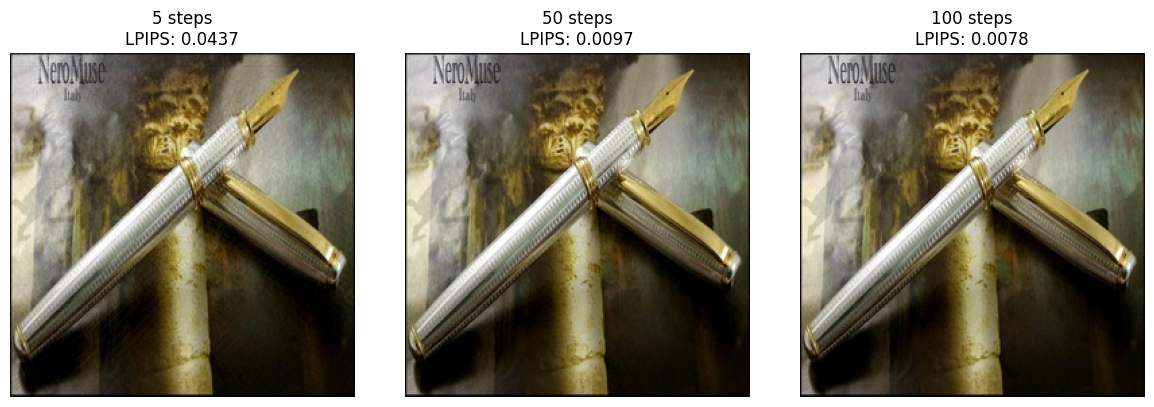

In [10]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import torch
import lpips
from torchvision.transforms.functional import to_tensor

# folders
run_compare_dirs = {
    5: DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k5_strongerblur",
    50: DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k50_strongerblur",
    100: DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k100_strongerblur",
}

# choose image index
idx = 97

# device
device = "cuda" if torch.cuda.is_available() else "cpu"

# LPIPS model
loss_fn = lpips.LPIPS(net='alex').to(device)
loss_fn.eval()

# use orig image as reference (can take it from any run folder)
ref_folder = run_compare_dirs[100]
ref_path = ref_folder / f"orig_{idx}.png"
ref_img = Image.open(ref_path).convert("RGB")

def pil_to_lpips_tensor(img):
    x = to_tensor(img).unsqueeze(0).to(device)   # [0,1]
    x = x * 2 - 1                                # [-1,1] for LPIPS
    return x

ref_tensor = pil_to_lpips_tensor(ref_img)

plt.figure(figsize=(12, 4))

for i, (k, folder) in enumerate(run_compare_dirs.items()):
    img_path = folder / f"{idx}_-1.png"
    img = Image.open(img_path).convert("RGB")

    img_tensor = pil_to_lpips_tensor(img)
    lpips_score = loss_fn(ref_tensor, img_tensor).item()

    plt.subplot(1, len(run_compare_dirs), i + 1)
    plt.imshow(img)
    plt.title(f"{k} steps\nLPIPS: {lpips_score:.4f}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Seeing the differences, we can tolerate an epsilon of 0.5 for this level of blur.

### Second experiment is with epsilon 0.3

In [9]:
def binary_search_kstar(pass_fn, low_k, high_k):
    """
    Finds the smallest k in [low_k+1, high_k] that passes.
    Assumes:
      - low_k fails
      - high_k passes
    """
    lo = low_k + 1
    hi = high_k

    while lo < hi:
        mid = (lo + hi) // 2
        if pass_fn(mid):
            hi = mid
        else:
            lo = mid + 1

    return lo


def make_pass_fn(lpips_by_step, best_lpips, epsilon):
    """
    lpips_by_step: dict {step: lpips}
    Returns a function pass_fn(k) that checks whether
    LPIPS at step k is within (1 + epsilon) of the best LPIPS.
    """
    threshold = (1 + epsilon) * best_lpips

    def pass_fn(k):
        if k not in lpips_by_step:
            raise ValueError(f"Missing LPIPS for step {k}")
        return lpips_by_step[k] <= threshold

    return pass_fn


def get_dense_steps_from_interval(low_k, high_k):
    """
    Returns all integer steps in the refinement interval.
    Example: (30, 50) -> [31, 32, ..., 50]
    """
    if low_k is None or high_k is None:
        return []
    return list(range(low_k + 1, high_k + 1))

In [23]:
# epsilon = 0.5
epsilon = 0.3
print(f"Refinement plan for epsilon = {epsilon}\n")

for idx in sorted(intervals):
    low_k, high_k = intervals[idx]
    
    if low_k is None:
        print(f"image={idx}: already passes at the smallest tested step")
    elif high_k is None:
        print(f"image={idx}: did not pass within tested range; test larger steps")
    else:
        dense_steps = get_dense_steps_from_interval(low_k, high_k)
        print(f"image={idx}: refine in [{low_k}, {high_k}] -> test {dense_steps}")

Refinement plan for epsilon = 0.3

image=0: refine in [66, 67] -> test [67]
image=1: refine in [52, 53] -> test [53]
image=2: refine in [20, 21] -> test [21]
image=3: refine in [50, 51] -> test [51]
image=4: refine in [38, 39] -> test [39]
image=5: refine in [33, 34] -> test [34]
image=6: refine in [58, 59] -> test [59]
image=7: refine in [55, 56] -> test [56]
image=8: refine in [58, 59] -> test [59]
image=9: refine in [47, 48] -> test [48]
image=10: refine in [13, 14] -> test [14]
image=11: refine in [37, 38] -> test [38]
image=12: refine in [27, 28] -> test [28]
image=13: refine in [35, 36] -> test [36]
image=14: refine in [52, 53] -> test [53]
image=15: refine in [52, 53] -> test [53]
image=16: refine in [43, 44] -> test [44]
image=17: refine in [62, 63] -> test [63]
image=18: refine in [52, 53] -> test [53]
image=19: refine in [56, 57] -> test [57]
image=20: refine in [66, 67] -> test [67]
image=21: refine in [55, 56] -> test [56]
image=22: refine in [35, 36] -> test [36]
image=23:

In [24]:
from collections import defaultdict

# build per-image LPIPS lookup
lpips_lookup = defaultdict(dict)

for idx, k, score in results:
    lpips_lookup[idx][k] = score

In [25]:
def make_pass_fn_for_image(idx, epsilon):
    best_lp = best_lpips[idx]
    threshold = (1 + epsilon) * best_lp

    def pass_fn(k):
        if k not in lpips_lookup[idx]:
            raise ValueError(f"LPIPS not computed yet for image {idx}, step {k}")
        return lpips_lookup[idx][k] <= threshold

    return pass_fn

def next_binary_step(idx, low_k, high_k):
    return (low_k + high_k) // 2

In [26]:
# epsilon = 0.5
epsilon = 0.3
print(f"Binary search suggestions (epsilon={epsilon}):\n")

tries = set()

for idx in sorted(intervals):
    low_k, high_k = intervals[idx]

    if low_k is None or high_k is None:
        print(f"image={idx}: no refinement needed")
        continue

    mid = next_binary_step(idx, low_k, high_k)

    tries.add(mid)
    
    print(f"image={idx}: try step {mid} (between {low_k} and {high_k})")


Binary search suggestions (epsilon=0.3):

image=0: try step 66 (between 66 and 67)
image=1: try step 52 (between 52 and 53)
image=2: try step 20 (between 20 and 21)
image=3: try step 50 (between 50 and 51)
image=4: try step 38 (between 38 and 39)
image=5: try step 33 (between 33 and 34)
image=6: try step 58 (between 58 and 59)
image=7: try step 55 (between 55 and 56)
image=8: try step 58 (between 58 and 59)
image=9: try step 47 (between 47 and 48)
image=10: try step 13 (between 13 and 14)
image=11: try step 37 (between 37 and 38)
image=12: try step 27 (between 27 and 28)
image=13: try step 35 (between 35 and 36)
image=14: try step 52 (between 52 and 53)
image=15: try step 52 (between 52 and 53)
image=16: try step 43 (between 43 and 44)
image=17: try step 62 (between 62 and 63)
image=18: try step 52 (between 52 and 53)
image=19: try step 56 (between 56 and 57)
image=20: try step 66 (between 66 and 67)
image=21: try step 55 (between 55 and 56)
image=22: try step 35 (between 35 and 36)
im

In [ ]:
tries

In [15]:
# Epsilon 0.5 exp
# run_dirs[7] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k7_strongerblur"
# run_dirs[15] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k15_strongerblur"
# run_dirs[25] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k25_strongerblur"
# run_dirs[40] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k40_strongerblur"
# run_dirs[75] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k75_strongerblur"


# Epsilon 0.3 exp
run_dirs[7] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k7_strongerblur"
run_dirs[15] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k15_strongerblur"
run_dirs[25] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k25_strongerblur"
run_dirs[40] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k40_strongerblur"
run_dirs[75] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k75_strongerblur"

In [16]:
# Epsilon 0.5 exp
# run_dirs[8] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k8_strongerblur"
# run_dirs[12] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k12_strongerblur"
# run_dirs[17] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k17_strongerblur"
# run_dirs[22] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k22_strongerblur"
# run_dirs[27] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k27_strongerblur"
# run_dirs[35] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k35_strongerblur"
# run_dirs[45] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k45_strongerblur"
# run_dirs[62] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k62_strongerblur"
# run_dirs[87] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k87_strongerblur"

# Epsilon 0.3 exp
run_dirs[6] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k6_strongerblur"
run_dirs[8] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k8_strongerblur"
run_dirs[12] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k12_strongerblur"
run_dirs[22] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k22_strongerblur"
run_dirs[27] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k27_strongerblur"
run_dirs[35] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k35_strongerblur"
run_dirs[45] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k45_strongerblur"
run_dirs[62] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k62_strongerblur"
run_dirs[87] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k87_strongerblur"

In [17]:
# Epsilon 0.5 exp
# run_dirs[11] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k11_strongerblur"
# run_dirs[13] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k13_strongerblur"
# run_dirs[16] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k16_strongerblur"
# run_dirs[18] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k18_strongerblur"
# run_dirs[21] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k21_strongerblur"
# run_dirs[23] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k23_strongerblur"
# run_dirs[26] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k26_strongerblur"
# run_dirs[28] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k28_strongerblur"
# run_dirs[32] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k32_strongerblur"
# run_dirs[37] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k37_strongerblur"
# run_dirs[42] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k42_strongerblur"
# run_dirs[47] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k47_strongerblur"
# run_dirs[56] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k56_strongerblur"
# run_dirs[68] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k68_strongerblur"
# run_dirs[81] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k81_strongerblur"

# Epsilon 0.3 exp
run_dirs[9] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k9_strongerblur"
run_dirs[13] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k13_strongerblur"
run_dirs[21] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k21_strongerblur"
run_dirs[23] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k23_strongerblur"
run_dirs[26] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k26_strongerblur"
run_dirs[28] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k28_strongerblur"
run_dirs[32] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k32_strongerblur"
run_dirs[37] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k37_strongerblur"
run_dirs[42] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k42_strongerblur"
run_dirs[47] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k47_strongerblur"
run_dirs[56] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k56_strongerblur"
run_dirs[68] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k68_strongerblur"
run_dirs[81] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k81_strongerblur"

In [18]:
# Epsilon 0.5 exp
# run_dirs[14] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k14_strongerblur"
# run_dirs[19] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k19_strongerblur"
# run_dirs[24] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k24_strongerblur"
# run_dirs[29] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k29_strongerblur"
# run_dirs[31] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k31_strongerblur"
# run_dirs[33] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k33_strongerblur"
# run_dirs[36] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k36_strongerblur"
# run_dirs[38] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k38_strongerblur"
# run_dirs[41] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k41_strongerblur"
# run_dirs[43] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k43_strongerblur"
# run_dirs[46] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k46_strongerblur"
# run_dirs[48] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k48_strongerblur"
# run_dirs[53] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k53_strongerblur"
# run_dirs[59] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k59_strongerblur"
# run_dirs[71] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k71_strongerblur"
# run_dirs[78] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k78_strongerblur"

# Epsilon 0.3 exp
run_dirs[14] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k14_strongerblur"
run_dirs[24] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k24_strongerblur"
run_dirs[29] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k29_strongerblur"
run_dirs[31] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k31_strongerblur"
run_dirs[33] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k33_strongerblur"
run_dirs[36] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k36_strongerblur"
run_dirs[38] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k38_strongerblur"
run_dirs[41] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k41_strongerblur"
run_dirs[43] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k43_strongerblur"
run_dirs[46] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k46_strongerblur"
run_dirs[48] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k48_strongerblur"
run_dirs[53] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k53_strongerblur"
run_dirs[59] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k59_strongerblur"
run_dirs[65] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k65_strongerblur"
run_dirs[71] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k71_strongerblur"
run_dirs[78] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k78_strongerblur"
run_dirs[84] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k84_strongerblur"

In [19]:
# Epsilon 0.5 exp
# run_dirs[34] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k34_strongerblur"
# run_dirs[39] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k39_strongerblur"
# run_dirs[44] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k44_strongerblur"
# run_dirs[51] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k51_strongerblur"
# run_dirs[54] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k54_strongerblur"
# run_dirs[57] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k57_strongerblur"
# run_dirs[73] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k73_strongerblur"
# run_dirs[76] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k76_strongerblur"

# Epsilon 0.3 exp
run_dirs[34] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k34_strongerblur"
run_dirs[39] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k39_strongerblur"
run_dirs[44] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k44_strongerblur"
run_dirs[51] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k51_strongerblur"
run_dirs[54] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k54_strongerblur"
run_dirs[57] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k57_strongerblur"
run_dirs[63] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k63_strongerblur"
run_dirs[66] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k66_strongerblur"
run_dirs[73] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k73_strongerblur"
run_dirs[76] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k76_strongerblur"
run_dirs[82] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k82_strongerblur"

In [20]:
# Epsilon 0.5 exp
# run_dirs[52] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k52_strongerblur"
# run_dirs[72] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k72_strongerblur"
# run_dirs[77] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR" / "run_imagenet100_k77_strongerblur"

# Epsilon 0.3 exp
run_dirs[52] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k52_strongerblur"
run_dirs[55] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k55_strongerblur"
run_dirs[58] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k58_strongerblur"
run_dirs[67] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k67_strongerblur"
run_dirs[72] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k72_strongerblur"
run_dirs[83] = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 STRONG BLUR EPS 0.3" / "run_imagenet100_k83_strongerblur"